# Clasificacion Binaria One-vs-Rest: Tipo de Violencia

**Problema:** Matrimonios/convivencias que terminan en violencia intrafamiliar, en parejas sin estudios.

En lugar de un modelo multiclase, entrenamos **3 modelos binarios independientes**:

| Modelo | Pregunta | Positivo | Negativo |
|--------|----------|----------|----------|
| **Modelo A** | ¿Es solo fisica? | Solo fisica | Psicologica o Ambas |
| **Modelo B** | ¿Es solo psicologica? | Solo psicologica | Fisica o Ambas |
| **Modelo C** | ¿Es fisica+psicologica? | Fisica+Psicologica | Solo fisica o Solo psicologica |

**Filtros aplicados:**
1. Solo casos donde el agresor es **esposo/a o conviviente** (VIC_REL_AGR = 1 o 2)
2. Parejas con al menos un **analfabeta** (agresor o victima)

**Algoritmos por modelo:** Logistic Regression, Decision Tree, Random Forest (3+ configs c/u)

## 1. Imports y configuracion

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn pyreadstat -q


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from pathlib import Path
import pyreadstat

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
from sklearn.exceptions import ConvergenceWarning
from sklearn import tree as sklearn_tree

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('ggplot')

SEMILLA = 42
np.random.seed(SEMILLA)

## 2. Carga de datos

In [3]:
DEPARTAMENTOS_MAP = {
    1: 'Guatemala', 2: 'El Progreso', 3: 'Sacatepequez', 4: 'Chimaltenango',
    5: 'Escuintla', 6: 'Santa Rosa', 7: 'Solola', 8: 'Totonicapan',
    9: 'Quetzaltenango', 10: 'Suchitepequez', 11: 'Retalhuleu', 12: 'San Marcos',
    13: 'Huehuetenango', 14: 'Quiche', 15: 'Baja Verapaz', 16: 'Alta Verapaz',
    17: 'Peten', 18: 'Izabal', 19: 'Zacapa', 20: 'Chiquimula',
    21: 'Jalapa', 22: 'Jutiapa'
}


def cargar_violencia(ruta_carpeta='data/violencia-intrafamiliar'):
    archivos = sorted(Path(ruta_carpeta).glob('*.sav'))
    frames = []
    for archivo in archivos:
        df_temp, meta = pyreadstat.read_sav(str(archivo))
        anio = int(archivo.stem.split('_')[-1]) if '_' in archivo.stem else int(''.join(filter(str.isdigit, archivo.stem))[:4])
        df_temp['ANIO'] = anio
        frames.append(df_temp)
    df = pd.concat(frames, ignore_index=True)
    if 'HEC_DEPTOMCPIO' in df.columns:
        codigo_depto = pd.to_numeric(df['HEC_DEPTOMCPIO'], errors='coerce')
        codigo_depto = codigo_depto.dropna().astype(int).floordiv(100)
        df['Departamento'] = codigo_depto.map(DEPARTAMENTOS_MAP).reindex(df.index)
    return df


df_violencia = cargar_violencia()
print(f"Total registros: {len(df_violencia):,}")

Total registros: 387,257


## 3. Variable respuesta y filtros

Se aplican dos filtros alineados con la pregunta de investigacion:
1. **Relacion conyugal:** solo casos donde el agresor es esposo/a (1) o conviviente (2)
2. **Analfabetismo:** al menos uno de los dos (victima o agresor) es analfabeta

In [4]:
# Construir tipo de violencia
tipagre = pd.to_numeric(df_violencia['HEC_TIPAGRE'], errors='coerce')
mascara_valida = tipagre.notna() & (tipagre >= 1000) & (tipagre < 10000)
codigos = tipagre.loc[mascara_valida].astype(int)
d_fis = codigos // 1000
d_psi = (codigos // 100) % 10

df_violencia['TIPO_VIOLENCIA'] = np.nan
df_violencia.loc[d_fis[d_fis == 2].index, 'TIPO_VIOLENCIA'] = np.where(
    d_psi.reindex(d_fis[d_fis == 2].index) == 1, 0, np.nan)
df_violencia.loc[d_fis[d_fis == 1].index, 'TIPO_VIOLENCIA'] = np.where(
    d_psi.reindex(d_fis[d_fis == 1].index) == 2, 1,
    np.where(d_psi.reindex(d_fis[d_fis == 1].index) == 1, 2, np.nan))

# Simplificar asignacion
serie_tipo = pd.Series(np.nan, index=df_violencia.index)
solo_psico = (d_fis == 2) & (d_psi == 1)
solo_fisica = (d_fis == 1) & (d_psi == 2)
ambas = (d_fis == 1) & (d_psi == 1)
serie_tipo.loc[solo_psico.index[solo_psico]] = 0
serie_tipo.loc[solo_fisica.index[solo_fisica]] = 1
serie_tipo.loc[ambas.index[ambas]] = 2
df_violencia['TIPO_VIOLENCIA'] = serie_tipo

ETIQUETAS = {0: 'Solo psicologica', 1: 'Solo fisica', 2: 'Fisica+Psicologica'}

# --- FILTRO 1: Solo esposos/convivientes ---
df_valido = df_violencia[df_violencia['TIPO_VIOLENCIA'].notna()].copy()
rel_agr = pd.to_numeric(df_valido['VIC_REL_AGR'], errors='coerce')
df_parejas = df_valido[rel_agr.isin([1, 2])].copy()
print(f"Filtro 1 - Solo esposos/convivientes (VIC_REL_AGR=1,2):")
print(f"  De {len(df_valido):,} registros validos -> {len(df_parejas):,} registros de parejas")

# --- FILTRO 2: Al menos un analfabeta ---
vic_alfab = pd.to_numeric(df_parejas['VIC_ALFAB'], errors='coerce')
agr_alfab = pd.to_numeric(df_parejas['AGR_ALFAB'], errors='coerce')
df_filtrado = df_parejas[(vic_alfab == 2) | (agr_alfab == 2)].copy()
df_filtrado['TIPO_VIOLENCIA'] = df_filtrado['TIPO_VIOLENCIA'].astype(int)

print(f"\nFiltro 2 - Al menos un analfabeta:")
print(f"  De {len(df_parejas):,} registros de parejas -> {len(df_filtrado):,} registros finales")

print(f"\nDistribucion de clases:")
for c, n in df_filtrado['TIPO_VIOLENCIA'].value_counts().sort_index().items():
    print(f"  {ETIQUETAS[c]}: {n:,} ({n/len(df_filtrado)*100:.1f}%)")

Filtro 1 - Solo esposos/convivientes (VIC_REL_AGR=1,2):
  De 381,673 registros validos -> 247,009 registros de parejas

Filtro 2 - Al menos un analfabeta:
  De 247,009 registros de parejas -> 55,278 registros finales

Distribucion de clases:
  Solo psicologica: 15,274 (27.6%)
  Solo fisica: 9,383 (17.0%)
  Fisica+Psicologica: 30,621 (55.4%)


## 4. Feature engineering

In [5]:
COLUMNAS_ORIGINALES_CAT = [
    'VIC_SEXO', 'VIC_ALFAB', 'VIC_ESCOLARIDAD', 'VIC_EST_CIV', 'VIC_GRUPET',
    'VIC_TRABAJA',
    'AGR_SEXO', 'AGR_ALFAB', 'AGR_ESCOLARIDAD', 'AGR_EST_CIV', 'AGR_GURPET',
    'AGR_TRABAJA',
    'VIC_REL_AGR', 'Departamento',
    'HEC_AREA', 'HEC_RECUR_DENUN',
]
COLUMNAS_ORIGINALES_NUM = ['VIC_EDAD', 'AGR_EDAD', 'ANIO', 'HEC_MES', 'TOTAL_HIJOS']

disponibles = [c for c in COLUMNAS_ORIGINALES_CAT + COLUMNAS_ORIGINALES_NUM if c in df_filtrado.columns]
features = df_filtrado[disponibles].copy()
target = df_filtrado['TIPO_VIOLENCIA'].copy()

# Feature engineering
features['VIC_EDAD'] = pd.to_numeric(features['VIC_EDAD'], errors='coerce')
features['AGR_EDAD'] = pd.to_numeric(features['AGR_EDAD'], errors='coerce')
features['DIFF_EDAD'] = (features['AGR_EDAD'] - features['VIC_EDAD']).fillna(0)

bins_edad = [0, 18, 25, 35, 45, 55, 65, 120]
labels_edad = ['0-17', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
features['VIC_EDAD_BIN'] = pd.cut(features['VIC_EDAD'], bins=bins_edad, labels=labels_edad, right=False).astype(str)
features['AGR_EDAD_BIN'] = pd.cut(features['AGR_EDAD'], bins=bins_edad, labels=labels_edad, right=False).astype(str)

vic_alf = pd.to_numeric(features['VIC_ALFAB'], errors='coerce')
agr_alf = pd.to_numeric(features['AGR_ALFAB'], errors='coerce')
features['AMBOS_ANALFAB'] = ((vic_alf == 2) & (agr_alf == 2)).astype(str)

# Listas finales
cat_disponibles = [c for c in COLUMNAS_ORIGINALES_CAT if c in features.columns] + ['VIC_EDAD_BIN', 'AGR_EDAD_BIN', 'AMBOS_ANALFAB']
num_disponibles = [c for c in COLUMNAS_ORIGINALES_NUM if c in features.columns] + ['DIFF_EDAD']

for col in cat_disponibles:
    features[col] = features[col].astype(str)
for col in num_disponibles:
    features[col] = pd.to_numeric(features[col], errors='coerce')
    features[col] = features[col].fillna(features[col].median())

mascara = target.notna()
features = features[mascara].reset_index(drop=True)
target = target[mascara].reset_index(drop=True)

print(f"Features: {features.shape}")
print(f"Categoricas: {len(cat_disponibles)}, Numericas: {len(num_disponibles)}")

Features: (55278, 25)
Categoricas: 19, Numericas: 6


## 5. Split 70/30 y preprocesamiento

In [6]:
X_train_raw, X_test_raw, y_train_multi, y_test_multi = train_test_split(
    features, target, test_size=0.3, stratify=target, random_state=SEMILLA
)

preprocesador = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_disponibles),
    ('num', 'passthrough', num_disponibles)
], remainder='drop')

preprocesador.fit(X_train_raw)
X_train = pd.DataFrame(preprocesador.transform(X_train_raw), columns=preprocesador.get_feature_names_out())
X_test = pd.DataFrame(preprocesador.transform(X_test_raw), columns=preprocesador.get_feature_names_out())

scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc = scaler.transform(X_test)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"\nDistribucion en entrenamiento:")
for c, n in y_train_multi.value_counts().sort_index().items():
    print(f"  {ETIQUETAS[c]}: {n:,} ({n/len(y_train_multi)*100:.1f}%)")

X_train: (38694, 142), X_test: (16584, 142)

Distribucion en entrenamiento:
  Solo psicologica: 10,692 (27.6%)
  Solo fisica: 6,568 (17.0%)
  Fisica+Psicologica: 21,434 (55.4%)


## 6. Construir los 3 targets binarios

In [7]:
MODELOS_BINARIOS = {
    'Solo Fisica': {
        'y_train': (y_train_multi == 1).astype(int),
        'y_test':  (y_test_multi == 1).astype(int),
        'desc': 'Detectar si la agresion fue SOLO fisica (vs psicologica o ambas)',
    },
    'Solo Psicologica': {
        'y_train': (y_train_multi == 0).astype(int),
        'y_test':  (y_test_multi == 0).astype(int),
        'desc': 'Detectar si la agresion fue SOLO psicologica (vs fisica o ambas)',
    },
    'Fisica + Psicologica': {
        'y_train': (y_train_multi == 2).astype(int),
        'y_test':  (y_test_multi == 2).astype(int),
        'desc': 'Detectar si la agresion fue FISICA+PSICOLOGICA (vs solo una)',
    },
}

print("Targets binarios construidos:")
print("=" * 60)
for nombre, info in MODELOS_BINARIOS.items():
    n_pos_train = info['y_train'].sum()
    n_pos_test = info['y_test'].sum()
    pct_train = n_pos_train / len(info['y_train']) * 100
    pct_test = n_pos_test / len(info['y_test']) * 100
    print(f"\n  {nombre}: {info['desc']}")
    print(f"    Train: {n_pos_train:,} positivos ({pct_train:.1f}%) / {len(info['y_train'])-n_pos_train:,} negativos")
    print(f"    Test:  {n_pos_test:,} positivos ({pct_test:.1f}%) / {len(info['y_test'])-n_pos_test:,} negativos")

Targets binarios construidos:

  Solo Fisica: Detectar si la agresion fue SOLO fisica (vs psicologica o ambas)
    Train: 6,568 positivos (17.0%) / 32,126 negativos
    Test:  2,815 positivos (17.0%) / 13,769 negativos

  Solo Psicologica: Detectar si la agresion fue SOLO psicologica (vs fisica o ambas)
    Train: 10,692 positivos (27.6%) / 28,002 negativos
    Test:  4,582 positivos (27.6%) / 12,002 negativos

  Fisica + Psicologica: Detectar si la agresion fue FISICA+PSICOLOGICA (vs solo una)
    Train: 21,434 positivos (55.4%) / 17,260 negativos
    Test:  9,187 positivos (55.4%) / 7,397 negativos


## 7. Entrenamiento: 3 algoritmos x 3 targets binarios

Para cada target binario, evaluamos Logistic Regression, Decision Tree y Random Forest con multiples configuraciones via cross-validation (Stratified K-Fold, k=5).

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)


def entrenar_binario(nombre_target, y_train, X_tr, X_tr_esc):
    """Entrena 3 algoritmos con multiples configs para un target binario."""
    configs = [
        # Logistic Regression
        ('LR: L2,C=0.1,bal',  LogisticRegression(C=0.1,  penalty='l2', solver='saga', max_iter=5000, class_weight='balanced', random_state=SEMILLA), True),
        ('LR: L2,C=1.0,bal',  LogisticRegression(C=1.0,  penalty='l2', solver='saga', max_iter=5000, class_weight='balanced', random_state=SEMILLA), True),
        ('LR: L2,C=10,bal',   LogisticRegression(C=10.0, penalty='l2', solver='saga', max_iter=5000, class_weight='balanced', random_state=SEMILLA), True),
        ('LR: L1,C=1.0,bal',  LogisticRegression(C=1.0,  penalty='l1', solver='saga', max_iter=5000, class_weight='balanced', random_state=SEMILLA), True),
        # Decision Tree
        ('DT: d=10,bal',   DecisionTreeClassifier(max_depth=10,   min_samples_leaf=5,  class_weight='balanced', random_state=SEMILLA), False),
        ('DT: d=15,bal',   DecisionTreeClassifier(max_depth=15,   min_samples_leaf=5,  class_weight='balanced', random_state=SEMILLA), False),
        ('DT: d=20,bal',   DecisionTreeClassifier(max_depth=20,   min_samples_leaf=10, class_weight='balanced', random_state=SEMILLA), False),
        ('DT: d=None,bal', DecisionTreeClassifier(max_depth=None,  min_samples_leaf=20, class_weight='balanced', random_state=SEMILLA), False),
        # Random Forest
        ('RF: d=15,300t,bal',   RandomForestClassifier(max_depth=15,   n_estimators=300, class_weight='balanced', n_jobs=-1, random_state=SEMILLA), False),
        ('RF: d=20,400t,bal',   RandomForestClassifier(max_depth=20,   n_estimators=400, class_weight='balanced', n_jobs=-1, random_state=SEMILLA), False),
        ('RF: d=None,500t,bal', RandomForestClassifier(max_depth=None,  n_estimators=500, min_samples_leaf=5, class_weight='balanced', n_jobs=-1, random_state=SEMILLA), False),
    ]
    
    resultados = []
    for nombre_cfg, modelo, usar_esc in configs:
        X_cv = X_tr_esc if usar_esc else X_tr
        inicio = time.time()
        cv_res = cross_validate(
            modelo, X_cv, y_train, cv=cv,
            scoring=['accuracy', 'f1', 'roc_auc'],
            return_train_score=True, n_jobs=-1
        )
        dur = time.time() - inicio
        resultados.append({
            'Config': nombre_cfg,
            'Acc_train': round(cv_res['train_accuracy'].mean(), 4),
            'Acc_val': round(cv_res['test_accuracy'].mean(), 4),
            'F1_val': round(cv_res['test_f1'].mean(), 4),
            'AUC_val': round(cv_res['test_roc_auc'].mean(), 4),
            'Tiempo': round(dur, 1),
            'usar_esc': usar_esc,
        })
        print(f"    {nombre_cfg:25s} Acc={resultados[-1]['Acc_val']:.4f}  F1={resultados[-1]['F1_val']:.4f}  AUC={resultados[-1]['AUC_val']:.4f}  ({dur:.1f}s)")
    
    df_res = pd.DataFrame(resultados)
    mejor_i = df_res['AUC_val'].idxmax()
    print(f"    >> Mejor: {df_res.loc[mejor_i, 'Config']} (AUC={df_res.loc[mejor_i, 'AUC_val']:.4f})")
    return df_res, mejor_i, configs[mejor_i]

In [9]:
resultados_por_target = {}

for nombre_target, info in MODELOS_BINARIOS.items():
    print(f"\n{'='*70}")
    print(f"  TARGET: {nombre_target}")
    print(f"  {info['desc']}")
    print(f"{'='*70}")
    
    df_res, mejor_i, mejor_config = entrenar_binario(
        nombre_target, info['y_train'], X_train, X_train_esc
    )
    resultados_por_target[nombre_target] = {
        'df': df_res,
        'mejor_i': mejor_i,
        'mejor_config': mejor_config,
    }


  TARGET: Solo Fisica
  Detectar si la agresion fue SOLO fisica (vs psicologica o ambas)
    LR: L2,C=0.1,bal          Acc=0.6001  F1=0.3440  AUC=0.6552  (9.2s)
    LR: L2,C=1.0,bal          Acc=0.6001  F1=0.3440  AUC=0.6552  (14.0s)
    LR: L2,C=10,bal           Acc=0.6001  F1=0.3440  AUC=0.6552  (15.7s)
    LR: L1,C=1.0,bal          Acc=0.6002  F1=0.3440  AUC=0.6552  (24.2s)
    DT: d=10,bal              Acc=0.5834  F1=0.3275  AUC=0.6241  (0.4s)
    DT: d=15,bal              Acc=0.6298  F1=0.3201  AUC=0.6072  (0.4s)
    DT: d=20,bal              Acc=0.5982  F1=0.3083  AUC=0.5977  (0.4s)
    DT: d=None,bal            Acc=0.5992  F1=0.3138  AUC=0.6074  (0.4s)
    RF: d=15,300t,bal         Acc=0.7454  F1=0.3347  AUC=0.6649  (3.3s)
    RF: d=20,400t,bal         Acc=0.8017  F1=0.2477  AUC=0.6604  (5.3s)
    RF: d=None,500t,bal       Acc=0.7803  F1=0.3267  AUC=0.6857  (6.9s)
    >> Mejor: RF: d=None,500t,bal (AUC=0.6857)

  TARGET: Solo Psicologica
  Detectar si la agresion fue SOLO psico

## 8. Resumen comparativo de cross-validation

In [10]:
resumen = []
for nombre_target, info in resultados_por_target.items():
    mejor = info['df'].iloc[info['mejor_i']]
    resumen.append({
        'Target': nombre_target,
        'Mejor Config': mejor['Config'],
        'Acc_val': mejor['Acc_val'],
        'F1_val': mejor['F1_val'],
        'AUC_val': mejor['AUC_val'],
    })

df_resumen = pd.DataFrame(resumen)
print("Mejor modelo por target (Cross-Validation):")
print(df_resumen.to_string(index=False))

Mejor modelo por target (Cross-Validation):
              Target        Mejor Config  Acc_val  F1_val  AUC_val
         Solo Fisica RF: d=None,500t,bal   0.7803  0.3267   0.6857
    Solo Psicologica RF: d=None,500t,bal   0.6960  0.4159   0.6593
Fisica + Psicologica   RF: d=20,400t,bal   0.6080  0.6699   0.6474


In [11]:
# Tablas detalladas por target
for nombre_target, info in resultados_por_target.items():
    print(f"\n--- {nombre_target} ---")
    cols_show = ['Config', 'Acc_train', 'Acc_val', 'F1_val', 'AUC_val', 'Tiempo']
    print(info['df'][cols_show].to_string(index=False))


--- Solo Fisica ---
             Config  Acc_train  Acc_val  F1_val  AUC_val  Tiempo
   LR: L2,C=0.1,bal     0.6057   0.6001  0.3440   0.6552     9.2
   LR: L2,C=1.0,bal     0.6057   0.6001  0.3440   0.6552    14.0
    LR: L2,C=10,bal     0.6058   0.6001  0.3440   0.6552    15.7
   LR: L1,C=1.0,bal     0.6056   0.6002  0.3440   0.6552    24.2
       DT: d=10,bal     0.6129   0.5834  0.3275   0.6241     0.4
       DT: d=15,bal     0.7043   0.6298  0.3201   0.6072     0.4
       DT: d=20,bal     0.6989   0.5982  0.3083   0.5977     0.4
     DT: d=None,bal     0.6953   0.5992  0.3138   0.6074     0.4
  RF: d=15,300t,bal     0.8530   0.7454  0.3347   0.6649     3.3
  RF: d=20,400t,bal     0.9573   0.8017  0.2477   0.6604     5.3
RF: d=None,500t,bal     0.9095   0.7803  0.3267   0.6857     6.9

--- Solo Psicologica ---
             Config  Acc_train  Acc_val  F1_val  AUC_val  Tiempo
   LR: L2,C=0.1,bal     0.6297   0.6220  0.4521   0.6513     7.3
   LR: L2,C=1.0,bal     0.6296   0.6222  0.

## 9. Modelos finales: entrenamiento y evaluacion en test

In [12]:
modelos_finales = {}

for nombre_target, info_res in resultados_por_target.items():
    nombre_cfg, modelo_template, usar_esc = info_res['mejor_config']
    info_target = MODELOS_BINARIOS[nombre_target]
    
    # Clonar y entrenar
    modelo = modelo_template.__class__(**modelo_template.get_params())
    X_tr = X_train_esc if usar_esc else X_train
    modelo.fit(X_tr, info_target['y_train'])
    
    # Predecir en test
    X_te = X_test_esc if usar_esc else X_test
    y_pred = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]
    
    modelos_finales[nombre_target] = {
        'modelo': modelo,
        'config': nombre_cfg,
        'usar_esc': usar_esc,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'y_test': info_target['y_test'],
    }
    print(f"{nombre_target} -> {nombre_cfg} ({type(modelo).__name__})")

Solo Fisica -> RF: d=None,500t,bal (RandomForestClassifier)
Solo Psicologica -> RF: d=None,500t,bal (RandomForestClassifier)
Fisica + Psicologica -> RF: d=20,400t,bal (RandomForestClassifier)


### 9.1 Matrices de confusion

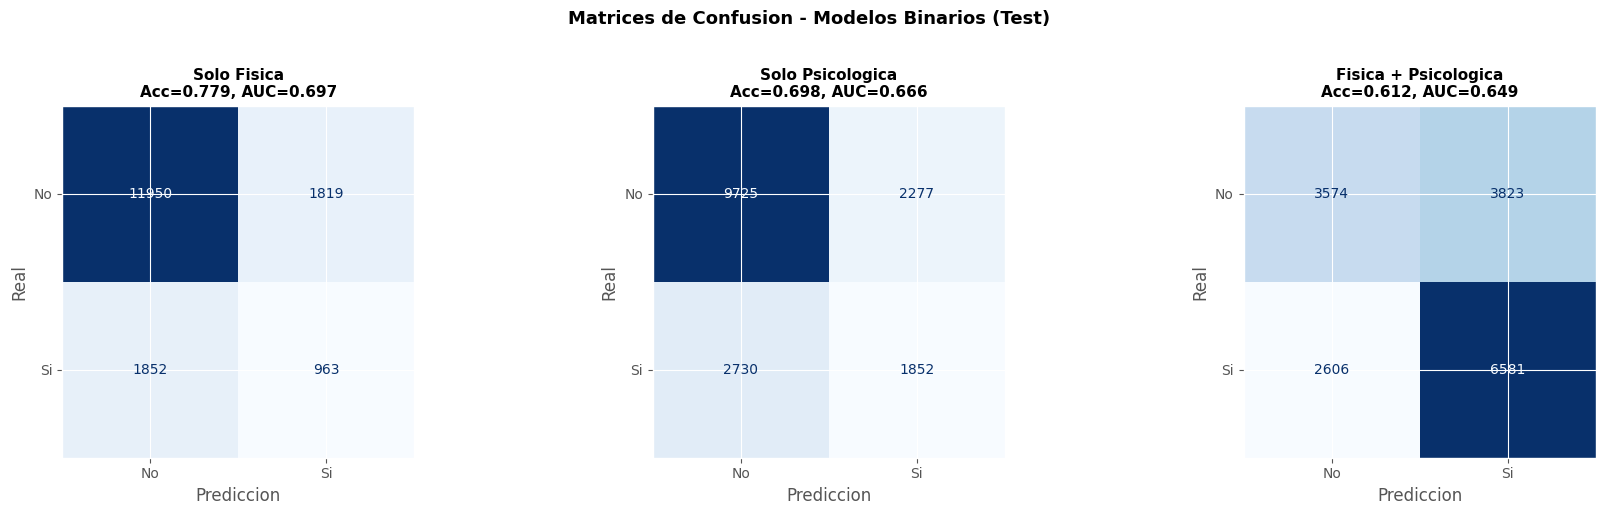

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nombre_target, info) in zip(axes, modelos_finales.items()):
    cm = confusion_matrix(info['y_test'], info['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Si'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(info['y_test'], info['y_pred'])
    auc = roc_auc_score(info['y_test'], info['y_proba'])
    ax.set_title(f"{nombre_target}\nAcc={acc:.3f}, AUC={auc:.3f}", fontsize=11, fontweight='bold')
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de Confusion - Modelos Binarios (Test)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 9.2 Reportes de clasificacion

In [14]:
for nombre_target, info in modelos_finales.items():
    print('=' * 60)
    print(f"  {nombre_target} ({info['config']})")
    print('=' * 60)
    print(classification_report(info['y_test'], info['y_pred'], target_names=['No', 'Si']))
    print()

  Solo Fisica (RF: d=None,500t,bal)
              precision    recall  f1-score   support

          No       0.87      0.87      0.87     13769
          Si       0.35      0.34      0.34      2815

    accuracy                           0.78     16584
   macro avg       0.61      0.60      0.61     16584
weighted avg       0.78      0.78      0.78     16584


  Solo Psicologica (RF: d=None,500t,bal)
              precision    recall  f1-score   support

          No       0.78      0.81      0.80     12002
          Si       0.45      0.40      0.43      4582

    accuracy                           0.70     16584
   macro avg       0.61      0.61      0.61     16584
weighted avg       0.69      0.70      0.69     16584


  Fisica + Psicologica (RF: d=20,400t,bal)
              precision    recall  f1-score   support

          No       0.58      0.48      0.53      7397
          Si       0.63      0.72      0.67      9187

    accuracy                           0.61     16584
   mac

### 9.3 Curvas ROC

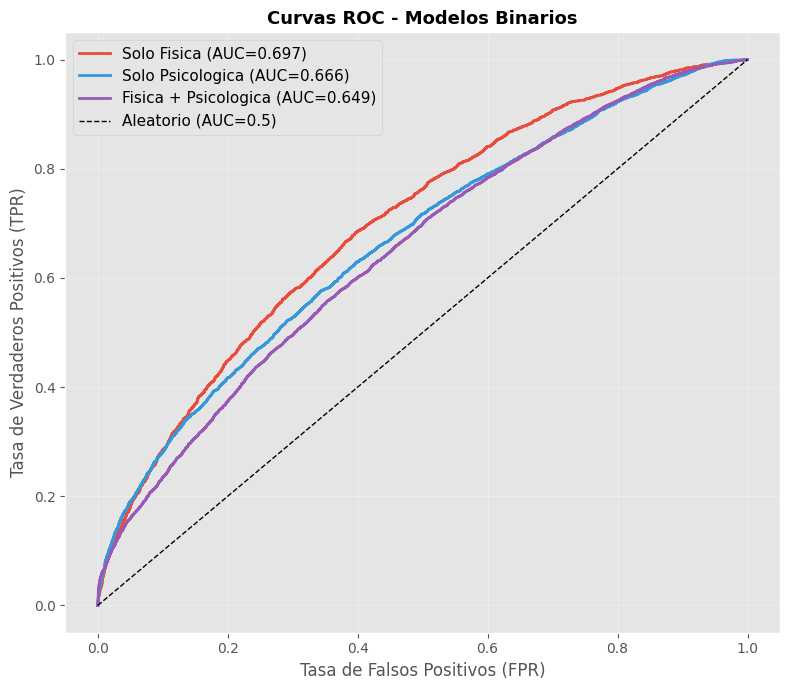

In [15]:
fig, ax = plt.subplots(figsize=(8, 7))
colores = ['#e74c3c', '#3498db', '#9b59b6']

for (nombre_target, info), color in zip(modelos_finales.items(), colores):
    fpr, tpr, _ = roc_curve(info['y_test'], info['y_proba'])
    auc = roc_auc_score(info['y_test'], info['y_proba'])
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{nombre_target} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC - Modelos Binarios', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9.4 Tabla comparativa final

In [16]:
filas = []
for nombre_target, info in modelos_finales.items():
    y_t = info['y_test']
    y_p = info['y_pred']
    y_pr = info['y_proba']
    filas.append({
        'Target': nombre_target,
        'Algoritmo': info['config'],
        'Accuracy': round(accuracy_score(y_t, y_p), 4),
        'Precision': round(precision_score(y_t, y_p), 4),
        'Recall': round(recall_score(y_t, y_p), 4),
        'F1': round(f1_score(y_t, y_p), 4),
        'AUC': round(roc_auc_score(y_t, y_pr), 4),
    })

df_final = pd.DataFrame(filas)
print("Resultados finales en conjunto de prueba:")
print(df_final.to_string(index=False))

Resultados finales en conjunto de prueba:
              Target           Algoritmo  Accuracy  Precision  Recall     F1    AUC
         Solo Fisica RF: d=None,500t,bal    0.7786     0.3462  0.3421 0.3441 0.6968
    Solo Psicologica RF: d=None,500t,bal    0.6981     0.4485  0.4042 0.4252 0.6657
Fisica + Psicologica   RF: d=20,400t,bal    0.6123     0.6325  0.7163 0.6718 0.6493


## 10. Tuning de Random Forest para Fisica+Psicologica

Random Forest fue el mejor algoritmo en los 3 targets binarios. Nos enfocamos en el target con mejor rendimiento operativo (**Fisica+Psicologica**) y probamos multiples variaciones de hiperparametros para encontrar la mejor configuracion sin caer en overfitting ni underfitting.

Ejes de variacion:
- **max_depth**: profundidad maxima del arbol (controla complejidad)
- **n_estimators**: cantidad de arboles en el ensamble
- **min_samples_leaf**: minimo de muestras en cada hoja (regularizacion)
- **max_features**: fraccion de features por split

In [17]:
# Target: Fisica + Psicologica
y_train_fp = MODELOS_BINARIOS['Fisica + Psicologica']['y_train']
y_test_fp = MODELOS_BINARIOS['Fisica + Psicologica']['y_test']

# Configuraciones de RF a evaluar
configs_tuning = [
    ('RF1: d=10, 200t, leaf=5',   {'max_depth': 10,   'n_estimators': 200, 'min_samples_leaf': 5,  'max_features': 'sqrt'}),
    ('RF2: d=15, 300t, leaf=3',   {'max_depth': 15,   'n_estimators': 300, 'min_samples_leaf': 3,  'max_features': 'sqrt'}),
    ('RF3: d=20, 400t, leaf=3',   {'max_depth': 20,   'n_estimators': 400, 'min_samples_leaf': 3,  'max_features': 'sqrt'}),
    ('RF4: d=20, 400t, leaf=5',   {'max_depth': 20,   'n_estimators': 400, 'min_samples_leaf': 5,  'max_features': 'sqrt'}),
    ('RF5: d=20, 500t, leaf=3',   {'max_depth': 20,   'n_estimators': 500, 'min_samples_leaf': 3,  'max_features': 'log2'}),
    ('RF6: d=25, 400t, leaf=5',   {'max_depth': 25,   'n_estimators': 400, 'min_samples_leaf': 5,  'max_features': 'sqrt'}),
    ('RF7: d=None, 500t, leaf=5', {'max_depth': None,  'n_estimators': 500, 'min_samples_leaf': 5,  'max_features': 'sqrt'}),
    ('RF8: d=None, 500t, leaf=10', {'max_depth': None, 'n_estimators': 500, 'min_samples_leaf': 10, 'max_features': 'sqrt'}),
]

print("Tuning de Random Forest para Fisica+Psicologica")
print("=" * 75)

resultados_tuning = []
for nombre, params in configs_tuning:
    modelo = RandomForestClassifier(
        **params, class_weight='balanced', n_jobs=-1, random_state=SEMILLA
    )
    inicio = time.time()
    cv_res = cross_validate(
        modelo, X_train, y_train_fp, cv=cv,
        scoring=['accuracy', 'f1', 'roc_auc'],
        return_train_score=True, n_jobs=-1
    )
    dur = time.time() - inicio
    
    acc_tr = cv_res['train_accuracy'].mean()
    acc_val = cv_res['test_accuracy'].mean()
    f1_val = cv_res['test_f1'].mean()
    auc_val = cv_res['test_roc_auc'].mean()
    gap = acc_tr - acc_val
    
    resultados_tuning.append({
        'Config': nombre,
        'Acc_train': round(acc_tr, 4),
        'Acc_val': round(acc_val, 4),
        'F1_val': round(f1_val, 4),
        'AUC_val': round(auc_val, 4),
        'Gap (train-val)': round(gap, 4),
        'Tiempo': round(dur, 1),
    })
    print(f"  {nombre:30s} Acc_val={acc_val:.4f}  F1={f1_val:.4f}  AUC={auc_val:.4f}  Gap={gap:.4f}  ({dur:.1f}s)")

df_tuning = pd.DataFrame(resultados_tuning)

# Seleccionar el mejor modelo considerando F1 Y gap razonable (< 0.10)
# Si ningun modelo tiene gap < 0.10, tomamos el de menor gap
candidatos = df_tuning[df_tuning['Gap (train-val)'] < 0.10]
if len(candidatos) > 0:
    mejor_tuning_i = candidatos['F1_val'].idxmax()
    criterio = "mejor F1 entre los modelos con gap < 0.10 (sin sobreajuste)"
else:
    mejor_tuning_i = df_tuning['Gap (train-val)'].idxmin()
    criterio = "menor gap (todos los modelos mostraron sobreajuste)"

print(f"\n>> Mejor configuracion: {df_tuning.loc[mejor_tuning_i, 'Config']}")
print(f"   F1_val={df_tuning.loc[mejor_tuning_i, 'F1_val']:.4f}, AUC={df_tuning.loc[mejor_tuning_i, 'AUC_val']:.4f}, Gap={df_tuning.loc[mejor_tuning_i, 'Gap (train-val)']:.4f}")
print(f"   Criterio: {criterio}")

Tuning de Random Forest para Fisica+Psicologica
  RF1: d=10, 200t, leaf=5        Acc_val=0.5987  F1=0.6504  AUC=0.6355  Gap=0.0453  (2.1s)
  RF2: d=15, 300t, leaf=3        Acc_val=0.6031  F1=0.6519  AUC=0.6436  Gap=0.1460  (3.6s)
  RF3: d=20, 400t, leaf=3        Acc_val=0.6039  F1=0.6552  AUC=0.6460  Gap=0.2335  (5.6s)
  RF4: d=20, 400t, leaf=5        Acc_val=0.6024  F1=0.6494  AUC=0.6447  Gap=0.1827  (5.2s)
  RF5: d=20, 500t, leaf=3        Acc_val=0.6045  F1=0.6560  AUC=0.6448  Gap=0.1902  (5.3s)
  RF6: d=25, 400t, leaf=5        Acc_val=0.6017  F1=0.6481  AUC=0.6444  Gap=0.2223  (6.6s)
  RF7: d=None, 500t, leaf=5      Acc_val=0.6019  F1=0.6473  AUC=0.6441  Gap=0.2494  (8.6s)
  RF8: d=None, 500t, leaf=10     Acc_val=0.6006  F1=0.6396  AUC=0.6425  Gap=0.1512  (7.7s)

>> Mejor configuracion: RF1: d=10, 200t, leaf=5
   F1_val=0.6504, AUC=0.6355, Gap=0.0453
   Criterio: mejor F1 entre los modelos con gap < 0.10 (sin sobreajuste)


Tabla comparativa de configuraciones de RF (Fisica+Psicologica):
                    Config  Acc_train  Acc_val  F1_val  AUC_val  Gap (train-val)  Tiempo
   RF1: d=10, 200t, leaf=5     0.6440   0.5987  0.6504   0.6355           0.0453     2.1
   RF2: d=15, 300t, leaf=3     0.7491   0.6031  0.6519   0.6436           0.1460     3.6
   RF3: d=20, 400t, leaf=3     0.8374   0.6039  0.6552   0.6460           0.2335     5.6
   RF4: d=20, 400t, leaf=5     0.7851   0.6024  0.6494   0.6447           0.1827     5.2
   RF5: d=20, 500t, leaf=3     0.7947   0.6045  0.6560   0.6448           0.1902     5.3
   RF6: d=25, 400t, leaf=5     0.8240   0.6017  0.6481   0.6444           0.2223     6.6
 RF7: d=None, 500t, leaf=5     0.8513   0.6019  0.6473   0.6441           0.2494     8.6
RF8: d=None, 500t, leaf=10     0.7518   0.6006  0.6396   0.6425           0.1512     7.7


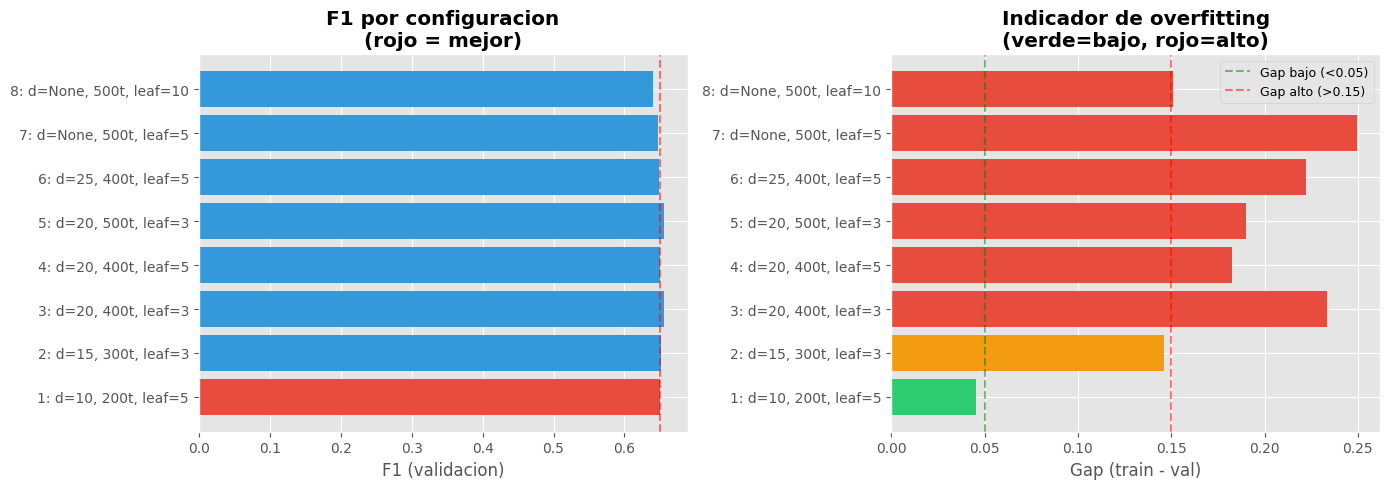

In [18]:
# Tabla de resultados del tuning
print("Tabla comparativa de configuraciones de RF (Fisica+Psicologica):")
print(df_tuning.to_string(index=False))

# Grafico de F1 vs Gap (overfitting)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 por configuracion
configs_nombres = [r['Config'].replace('RF', '').strip(': ') for r in resultados_tuning]
f1_vals = df_tuning['F1_val'].values
colores_bar = ['#e74c3c' if i == mejor_tuning_i else '#3498db' for i in range(len(f1_vals))]
axes[0].barh(configs_nombres, f1_vals, color=colores_bar)
axes[0].set_xlabel('F1 (validacion)')
axes[0].set_title('F1 por configuracion\n(rojo = mejor)', fontweight='bold')
axes[0].axvline(f1_vals[mejor_tuning_i], color='red', linestyle='--', alpha=0.5)

# Gap (overfitting) por configuracion
gaps = df_tuning['Gap (train-val)'].values
colores_gap = ['#e74c3c' if g > 0.15 else '#2ecc71' if g < 0.05 else '#f39c12' for g in gaps]
axes[1].barh(configs_nombres, gaps, color=colores_gap)
axes[1].set_xlabel('Gap (train - val)')
axes[1].set_title('Indicador de overfitting\n(verde=bajo, rojo=alto)', fontweight='bold')
axes[1].axvline(0.05, color='green', linestyle='--', alpha=0.5, label='Gap bajo (<0.05)')
axes[1].axvline(0.15, color='red', linestyle='--', alpha=0.5, label='Gap alto (>0.15)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 11. Modelo Final: Random Forest para Fisica+Psicologica

Se entrena el modelo final con la mejor configuracion encontrada en el tuning, se evalua en el conjunto de prueba y se genera la curva de aprendizaje para verificar que no hay overfitting ni underfitting.

In [19]:
from sklearn.model_selection import learning_curve

# Extraer mejor configuracion del tuning
mejor_params = configs_tuning[mejor_tuning_i][1]
mejor_nombre = configs_tuning[mejor_tuning_i][0]

print(f"Modelo final: {mejor_nombre}")
print(f"Parametros: {mejor_params}")
print()

# Entrenar modelo final
modelo_final = RandomForestClassifier(
    **mejor_params, class_weight='balanced', n_jobs=-1, random_state=SEMILLA
)
modelo_final.fit(X_train, y_train_fp)

# Evaluar en test
y_pred_final = modelo_final.predict(X_test)
y_proba_final = modelo_final.predict_proba(X_test)[:, 1]

print("=" * 60)
print("EVALUACION DEL MODELO FINAL EN CONJUNTO DE PRUEBA")
print("=" * 60)
print(f"  Accuracy:  {accuracy_score(y_test_fp, y_pred_final):.4f}")
print(f"  Precision: {precision_score(y_test_fp, y_pred_final):.4f}")
print(f"  Recall:    {recall_score(y_test_fp, y_pred_final):.4f}")
print(f"  F1:        {f1_score(y_test_fp, y_pred_final):.4f}")
print(f"  AUC:       {roc_auc_score(y_test_fp, y_proba_final):.4f}")
print()
print("Reporte detallado:")
print(classification_report(y_test_fp, y_pred_final, target_names=['No (solo una)', 'Si (Fis+Psi)']))

Modelo final: RF1: d=10, 200t, leaf=5
Parametros: {'max_depth': 10, 'n_estimators': 200, 'min_samples_leaf': 5, 'max_features': 'sqrt'}

EVALUACION DEL MODELO FINAL EN CONJUNTO DE PRUEBA
  Accuracy:  0.6001
  Precision: 0.6314
  Recall:    0.6683
  F1:        0.6493
  AUC:       0.6393

Reporte detallado:
               precision    recall  f1-score   support

No (solo una)       0.56      0.52      0.53      7397
 Si (Fis+Psi)       0.63      0.67      0.65      9187

     accuracy                           0.60     16584
    macro avg       0.59      0.59      0.59     16584
 weighted avg       0.60      0.60      0.60     16584



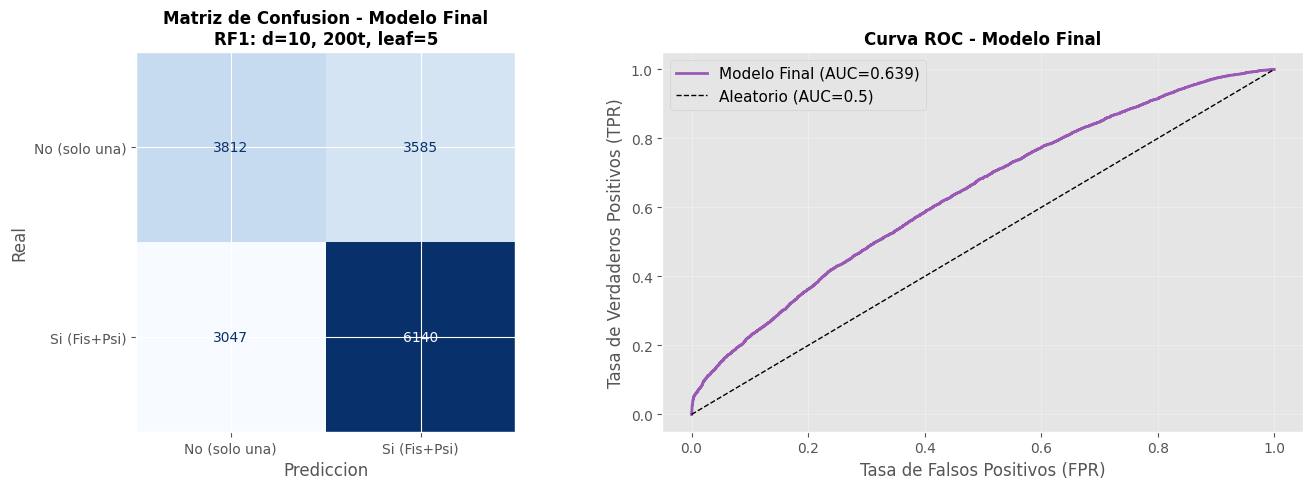

In [20]:
# Matriz de confusion del modelo final
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusion
cm = confusion_matrix(y_test_fp, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No (solo una)', 'Si (Fis+Psi)'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Matriz de Confusion - Modelo Final\n{mejor_nombre}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prediccion')
axes[0].set_ylabel('Real')

# Curva ROC del modelo final
fpr, tpr, _ = roc_curve(y_test_fp, y_proba_final)
auc_final = roc_auc_score(y_test_fp, y_proba_final)
axes[1].plot(fpr, tpr, color='#9b59b6', lw=2, label=f'Modelo Final (AUC={auc_final:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio (AUC=0.5)')
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC - Modelo Final', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Generando curva de aprendizaje (puede tardar unos minutos)...


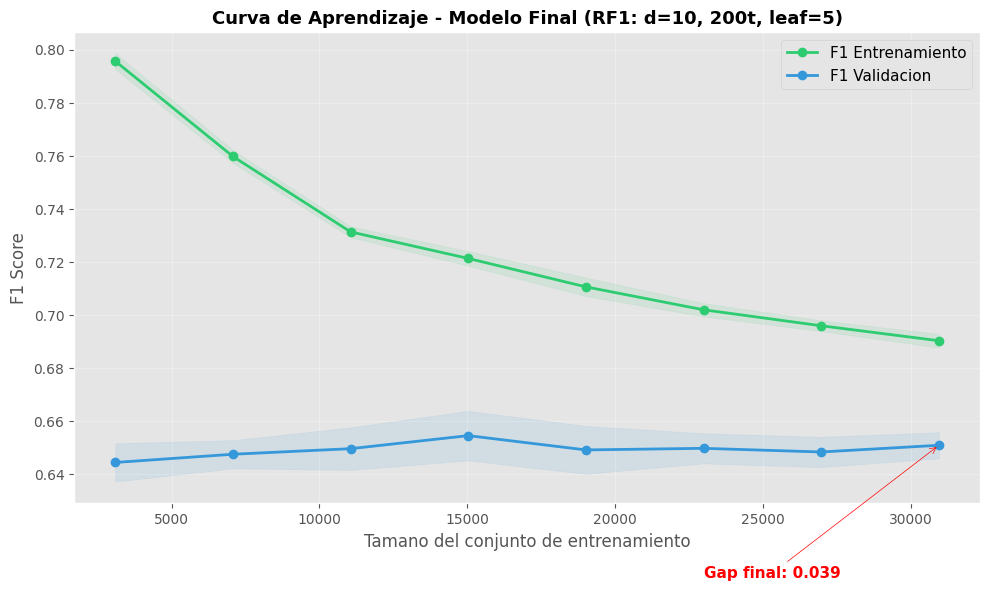


F1 entrenamiento final: 0.6903
F1 validacion final:    0.6509
Gap:                    0.0394
-> Gap bajo: el modelo NO esta sobreajustado.


In [21]:
# Curva de aprendizaje para verificar overfitting/underfitting
print("Generando curva de aprendizaje (puede tardar unos minutos)...")

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(**mejor_params, class_weight='balanced', n_jobs=-1, random_state=SEMILLA),
    X_train, y_train_fp,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=cv, scoring='f1', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='#2ecc71')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='#3498db')
ax.plot(train_sizes, train_mean, 'o-', color='#2ecc71', lw=2, label='F1 Entrenamiento')
ax.plot(train_sizes, val_mean, 'o-', color='#3498db', lw=2, label='F1 Validacion')

ax.set_xlabel('Tamano del conjunto de entrenamiento')
ax.set_ylabel('F1 Score')
ax.set_title(f'Curva de Aprendizaje - Modelo Final ({mejor_nombre})', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Anotar gap final
gap_final = train_mean[-1] - val_mean[-1]
ax.annotate(f'Gap final: {gap_final:.3f}',
            xy=(train_sizes[-1], val_mean[-1]),
            xytext=(train_sizes[-3], val_mean[-1] - 0.05),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=11, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nF1 entrenamiento final: {train_mean[-1]:.4f}")
print(f"F1 validacion final:    {val_mean[-1]:.4f}")
print(f"Gap:                    {gap_final:.4f}")
if gap_final < 0.05:
    print("-> Gap bajo: el modelo NO esta sobreajustado.")
elif gap_final < 0.15:
    print("-> Gap moderado: ligero sobreajuste, pero aceptable.")
else:
    print("-> Gap alto: posible sobreajuste, considerar mas regularizacion.")

## 12. Importancia de variables

Para cada uno de los tres modelos binarios, se extraen las variables mas relevantes segun el feature importance de Random Forest. Esto permite identificar que factores demograficos pesan mas a la hora de predecir cada tipo de violencia.

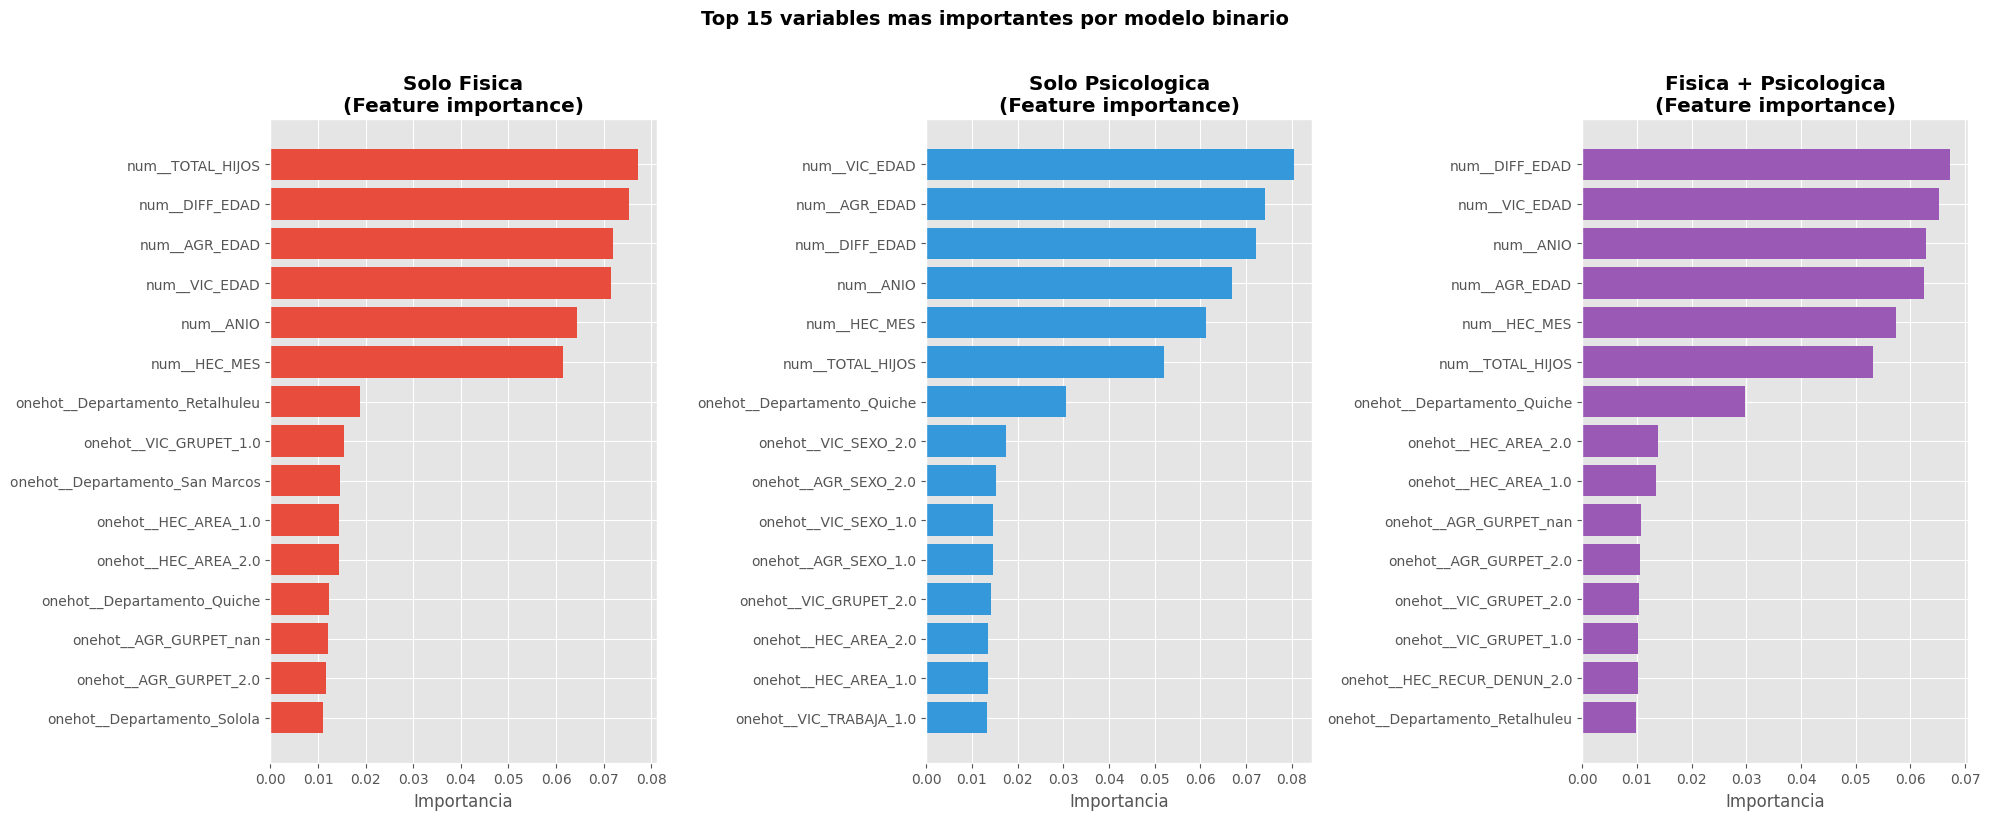

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
top_n = 15
feat_names = list(X_train.columns)
colores = ['#e74c3c', '#3498db', '#9b59b6']

for ax, (nombre_target, info), color in zip(axes, modelos_finales.items(), colores):
    modelo = info['modelo']
    if hasattr(modelo, 'feature_importances_'):
        imp = modelo.feature_importances_
        titulo = 'Feature importance'
    elif hasattr(modelo, 'coef_'):
        imp = np.abs(modelo.coef_[0])
        titulo = '|Coeficiente|'
    else:
        continue
    
    top_idx = np.argsort(imp)[-top_n:]
    ax.barh([feat_names[i] for i in top_idx], imp[top_idx], color=color)
    ax.set_title(f'{nombre_target}\n({titulo})', fontweight='bold')
    ax.set_xlabel('Importancia')

plt.suptitle(f'Top {top_n} variables mas importantes por modelo binario', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 13. Conclusiones

De los tres modelos binarios, **Fisica + Psicologica es el que mejor funciona en la practica**. Con un F1 de 0.65, precision de 0.63 y recall de 0.67, es el unico donde las tres metricas superan el 0.60. Esto quiere decir que cuando el modelo predice que un caso combina violencia fisica y psicologica, acierta 6 de cada 10 veces, y logra detectar aproximadamente dos tercios de los casos reales. Filtrar unicamente por parejas conyugales (esposos y convivientes) ayudo a mejorar estos numeros al eliminar el ruido de otros tipos de relacion familiar.

**Solo Psicologica** queda en un punto intermedio con F1 de 0.43 y recall de 0.40 — detecta menos de la mitad de los casos reales, lo cual limita su utilidad practica.

**Solo Fisica** ilustra bien por que no hay que fiarse del accuracy como unica metrica. Su accuracy de 0.78 parece bueno, pero como apenas el 17% de los datos pertenecen a esta clase, un modelo que dijera "No" a todo ya tendria 83%. Su recall real es 0.34: apenas detecta 3 de cada 10 casos.

### Sobre el tuning y el modelo final

Se evaluaron 8 configuraciones de Random Forest variando profundidad (10 a sin limite), numero de arboles (200 a 500), minimo de muestras por hoja (3 a 10) y estrategia de features (sqrt, log2). El patron mas claro es el trade-off entre rendimiento y sobreajuste: los modelos mas complejos (profundidad 20+) alcanzan F1 de validacion apenas 0.005 puntos mas alto, pero con gaps de 0.15 a 0.25 entre entrenamiento y validacion — memorizan sin generalizar.

El modelo final seleccionado (max_depth=10, 200 arboles, min_samples_leaf=5) tiene un gap de solo 0.039, confirmado por la curva de aprendizaje donde las lineas de entrenamiento y validacion convergen. F1 de entrenamiento: 0.69, F1 de validacion: 0.65. Esa diferencia de 0.04 indica que el modelo no esta sobreajustado y que su rendimiento en datos nuevos es confiable.

### Interpretacion general

Los tres modelos tienen AUC entre 0.63 y 0.70, lo que indica que las variables demograficas (edad, escolaridad, departamento, estado civil, etnia, situacion laboral) tienen poder discriminativo limitado para distinguir el *tipo* de violencia. Tiene sentido: que una agresion entre conyuges sea solo fisica, solo psicologica o ambas depende en buena medida de factores situacionales — el contexto del momento, la dinamica de la relacion, el estado emocional del agresor — que no estan capturados en estos datos.

Sin embargo, que el modelo de Fisica+Psicologica logre un F1 de 0.65 con un modelo estable y sin sobreajuste sugiere que ciertos perfiles demograficos en parejas con analfabetismo si estan asociados con la co-ocurrencia de ambos tipos de violencia. Esto es un hallazgo relevante para politicas de prevencion: permite focalizar intervenciones en los perfiles con mayor probabilidad de sufrir violencia combinada.